# 🧠 Neural Network — Painting Style Classification
โมเดล: MobileNetV2 (Transfer Learning) + Fine-tuning

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = '../dataset2_painting/images/images'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TOP_N_ARTISTS = 10

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# ── เลือก Top N Artists ──────────────────────────────────────────
class_counts = {}
for artist in os.listdir(DATASET_PATH):
    p = os.path.join(DATASET_PATH, artist)
    if os.path.isdir(p):
        class_counts[artist] = len(os.listdir(p))

top_artists = sorted(class_counts, key=class_counts.get, reverse=True)[:TOP_N_ARTISTS]
print('ศิลปินที่เลือก:', top_artists)
NUM_CLASSES = len(top_artists)

ศิลปินที่เลือก: ['Vincent_van_Gogh', 'Edgar_Degas', 'Pablo_Picasso', 'Pierre-Auguste_Renoir', 'Albrecht_Durer', 'Paul_Gauguin', 'Francisco_Goya', 'Rembrandt', 'Alfred_Sisley', 'Titian']


In [3]:
# ── สร้าง Subset Dataset ─────────────────────────────────────────
import shutil
SUBSET_PATH = '../dataset2_painting/subset'
if os.path.exists(SUBSET_PATH):
    shutil.rmtree(SUBSET_PATH)
for artist in top_artists:
    src = os.path.join(DATASET_PATH, artist)
    dst = os.path.join(SUBSET_PATH, artist)
    shutil.copytree(src, dst)
print(f'Subset created: {TOP_N_ARTISTS} artists')

Subset created: 10 artists


In [4]:
# ── Data Generators ──────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    SUBSET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42
)
val_gen = train_datagen.flow_from_directory(
    SUBSET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42
)
print(f'Train: {train_gen.samples}, Val: {val_gen.samples}')

Found 3252 images belonging to 10 classes.
Found 808 images belonging to 10 classes.
Train: 3252, Val: 808


In [5]:
# ── สร้าง Model ──────────────────────────────────────────────────
base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# ── Phase 1: Train ───────────────────────────────────────────────
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]
print('Phase 1: Training...')
history1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=callbacks)

Phase 1: Training...
Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.3951 - loss: 1.7560 - val_accuracy: 0.5916 - val_loss: 1.2168 - learning_rate: 0.0010
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 53s 515ms/step - accuracy: 0.5554 - loss: 1.2600 - val_accuracy: 0.6485 - val_loss: 1.0301 - learning_rate: 0.0010
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 694ms/step - accuracy: 0.6196 - loss: 1.0889 - val_accuracy: 0.6757 - val_loss: 0.9529 - learning_rate: 0.0010
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 514ms/step - accuracy: 0.6584 - loss: 0.9835 - val_accuracy: 0.6955 - val_loss: 0.8717 - learning_rate: 0.0010
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 527ms/step - accuracy: 0.6851 - loss: 0.9135 - val_accuracy: 0.7104 - val_loss: 0.8447 - learning_rate: 0.0010
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 545ms/step - accuracy: 0.6983 - loss: 0.8633 - val_accuracy: 0.7203 - val_loss: 0.8084 - learning_rate: 0.0010
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 529ms/s

In [7]:
# ── Phase 2: Fine-tuning ─────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])
print('Phase 2: Fine-tuning...')
history2 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks)

Phase 2: Fine-tuning...
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 580ms/step - accuracy: 0.6642 - loss: 1.0412 - val_accuracy: 0.7550 - val_loss: 0.7266 - learning_rate: 1.0000e-05
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 70s 691ms/step - accuracy: 0.7119 - loss: 0.8387 - val_accuracy: 0.7624 - val_loss: 0.7318 - learning_rate: 1.0000e-05
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 109s 940ms/step - accuracy: 0.7555 - loss: 0.7129 - val_accuracy: 0.7760 - val_loss: 0.6983 - learning_rate: 1.0000e-05
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 61s 598ms/step - accuracy: 0.7580 - loss: 0.7068 - val_accuracy: 0.7574 - val_loss: 0.7362 - learning_rate: 5.0000e-06
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 546ms/step - accuracy: 0.7629 - loss: 0.6708 - val_accuracy: 0.7661 - val_loss: 0.7216 - learning_rate: 5.0000e-06


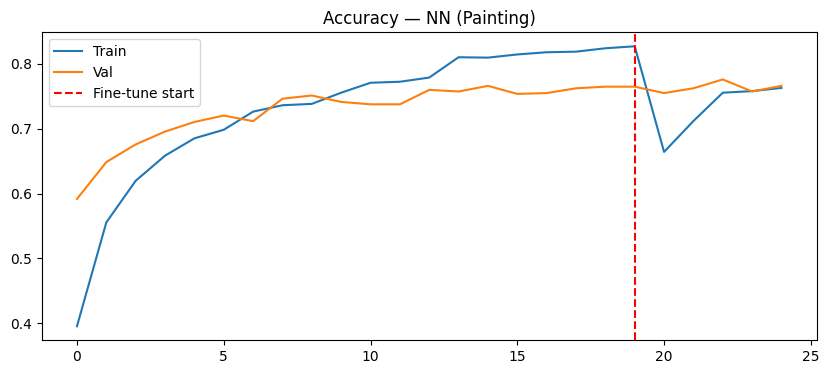

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 424ms/step - accuracy: 0.7698 - loss: 0.7065


Val Accuracy: 0.7698 (76.98%)
บันทึกโมเดลแล้ว


In [8]:
# ── Plot + Evaluate ──────────────────────────────────────────────
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
plt.figure(figsize=(10, 4))
plt.plot(acc, label='Train')
plt.plot(val_acc, label='Val')
plt.axvline(x=len(history1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tune start')
plt.title('Accuracy — NN (Painting)')
plt.legend()
plt.savefig('../models/training_history_nn.png')
plt.show()

loss, acc = model.evaluate(val_gen)
print(f'Val Accuracy: {acc:.4f} ({acc*100:.2f}%)')

# บันทึก class names
import json
class_names = list(train_gen.class_indices.keys())
with open('../models/painting_classes.json', 'w') as f:
    json.dump(class_names, f)

os.makedirs('../models', exist_ok=True)
model.save('../models/cnn_model.h5')
print('บันทึกโมเดลแล้ว')